In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from skbio.diversity import alpha_diversity, beta_diversity
from skbio.stats.ordination import pcoa
from skbio.stats.distance import permanova
from skbio.stats import subsample_counts

np.random.seed(42)
sns.set_style("whitegrid")

UPLOADS = "."  # current directory

In [138]:
from skbio import DistanceMatrix
from skbio.diversity import alpha_diversity, beta_diversity
from skbio.stats import subsample_counts
from skbio.stats.distance import permanova, permdisp, mantel
from skbio.stats.ordination import pcoa

In [139]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

## 1) Metadata Cleaning

I dropped`#q2:types` row that declares each column as `categorical` or `numeric`, since it's not a real sample.
Then I manually converted the objects that are supposed to be numeric values (they came in as object because of the type row). 

In [151]:
metadata = pd.read_csv(f"{UPLOADS}/bug.microbiome.metadata.tsv", sep="\t")
metadata = metadata[metadata["sample-id"] != "#q2:types"].reset_index(drop=True)

for c in ["year", "latitude", "longitude", "temp_degF",
          "relative_humidity", "windspeed_mph", "D_ng_ul", "A260_280"]:
    metadata[c] = pd.to_numeric(metadata[c], errors="coerce")

**Checking if any sample id is duplicate**

In [152]:
duplicate_sample_ids = metadata[
    metadata["sample-id"].duplicated(keep=False)
].sort_values("sample-id")

print(duplicate_sample_ids)

        sample-id IMR quality control voucher image species  stage morph sex  \
100  FJ190108-017              failed          TRUE    Jhae  adult    LW   f   
101  FJ190108-017              passed          TRUE    Jhae  adult    LW   f   

       year    month       city site_name   latitude  longitude host_plant  \
100  2019.0  January  Bartow FL    Bartow  27.954928 -81.770756        GRT   
101  2019.0  January  Bartow FL    Bartow  27.954928 -81.770756        GRT   

     temp_degF  relative_humidity  windspeed_mph  D_ng_ul  A260_280  \
100       85.0               42.8            0.9    75.04      2.22   
101       85.0               42.8            0.9    75.04      2.22   

    Adjusted for sequencing conc.  
100                           Yes  
101                           NaN  


**I only kept the samples that passed IMR Quality Control.**

In [153]:
metadata_cleaned = metadata[metadata["IMR quality control"] == "passed"].copy()
print(f"{len(metadata)} -> {len(metadata_cleaned)} samples after QC")
metadata_cleaned.head(3)

204 -> 163 samples after QC


,sample-id,IMR quality control,voucher image,species,stage,morph,sex,year,month,city,site_name,latitude,longitude,host_plant,temp_degF,relative_humidity,windspeed_mph,D_ng_ul,A260_280,Adjusted for sequencing conc.
1,DRA190110-002,passed,FALSE,Jhae,adult,SW,f,2019.0,January,Fort Lauderdale FL,Tamarac,26.188383,-80.172008,GRT,68.1,20.8,2.6,220.64,2.17,diluted to 173.0
3,DRA190110-004,passed,FALSE,Jhae,adult,SW,f,2019.0,January,Fort Lauderdale FL,Tamarac,26.188383,-80.172008,GRT,68.1,20.8,2.6,155.80,2.19,Yes
5,DRA190110-006,passed,TRUE,Jhae,adult,SW,f,2019.0,January,Fort Lauderdale FL,Tamarac,26.188383,-80.172008,GRT,68.1,20.8,2.6,28.20,2.28,Yes


## 2) Feature Table Cleaning

In [154]:
feature = pd.read_csv(f"{UPLOADS}/16s.v4.AFiles.feature.table.tsv",
                   sep="\t", skiprows=1)
feature_table = feature.rename(columns={"#OTU ID": "feature_id"}).set_index("feature_id")

**Checking for duplicates**

In [155]:
exact_duplicates = feature_table.columns[feature_table.columns.duplicated()].tolist()

print("Exact duplicate sample columns:")
print(exact_duplicates)

Exact duplicate sample columns:
[]


**Clarification: I saw in the tsv file that one sample had plate1, plate2. I tried searching what these are and it seems they are techincal replicates for the one sample. Since it's from one sample, I just summed it. In the metadata, that sample name only appears twice without specifying plate, so I don't know which one is plate 1 or plate 2 in the metadata. One of them doesn't pass IMR quality, so I dropped one. I still summed the plated for feature table because I thought it shouldn't matter that much even if one of their metadata is dropped since it's kind of the same and in data analysis, we fill in missing values and work with NaN values a lot ususally. So, summing and using the data as unified one should be still reasonable as long as I don't need to do it for a lot of samples. If you want me to do it any other way, I will do it!**

Though I pinpointed plate1 and plate 2 for one sample by just looking at the tsv, I thought I should still write a code for it generalizing the process, in case make the dataset bigger in future, where it mighht be hard to see such differences. 

In [156]:
sample_columns = feature_table.columns.tolist()
base_names = []

for sample in sample_columns:
    base = sample.replace("_plate1", "")
    base = base.replace("_plate2", "")
    base = base.replace("_plate3", "")
    base_names.append(base)

duplicate_check = pd.DataFrame({
    "original_sample_name": sample_columns,
    "base_sample_name": base_names
})

possible_replicates = duplicate_check[
    duplicate_check["base_sample_name"].duplicated(keep=False)
].sort_values("base_sample_name")

print("\nPossible technical replicates / plate duplicates:")
print(possible_replicates)


Possible technical replicates / plate duplicates:
    original_sample_name base_sample_name
100  FJ190108-017_plate1     FJ190108-017
101  FJ190108-017_plate2     FJ190108-017


In [157]:
if "FJ190108-017_plate1" in feature_table.columns:
    feature_table["FJ190108-017"] = (feature_table["FJ190108-017_plate1"]
                          + feature_table["FJ190108-017_plate2"])
    feature_table = feature_table.drop(columns=["FJ190108-017_plate1", "FJ190108-017_plate2"])

keep = [s for s in metadata_cleaned["sample-id"] if s in feature_table.columns]
feature_table_cleaned = feature_table[keep]
feature_table_cleaned = feature_table_cleaned.loc[feature_table_cleaned.sum(axis=1) > 0]
print(f"Cleaned feature table: {feature_table_cleaned.shape[0]} ASVs x {feature_table_cleaned.shape[1]} samples")

Cleaned feature table: 2578 ASVs x 163 samples


## 3)Taxonomy Table Cleaning

### I took each taxonomy string and splitted it into separate biological levels like phylum, class, order, family, genus, species so that it's easier to wrork with this data.

In [158]:
tax = pd.read_csv(
    f"{UPLOADS}/16s.v4.AFiles.silva138.taxonomy.tsv",
    sep="\t"
)

tax = tax.rename(columns={"Feature ID": "feature_id"})

def get_rank(taxon_string, prefix):
    if pd.isna(taxon_string):
        return np.nan
    
    parts = taxon_string.split(";")
    
    for part in parts:
        part = part.strip()
        
        if part.startswith(prefix):
            value = part.replace(prefix, "")
            
            if value == "":
                return np.nan
            else:
                return value
    
    return np.nan

tax["domain"] = tax["Taxon"].apply(lambda x: get_rank(x, "d__"))
tax["phylum"] = tax["Taxon"].apply(lambda x: get_rank(x, "p__"))
tax["class"] = tax["Taxon"].apply(lambda x: get_rank(x, "c__"))
tax["order"] = tax["Taxon"].apply(lambda x: get_rank(x, "o__"))
tax["family"] = tax["Taxon"].apply(lambda x: get_rank(x, "f__"))
tax["genus"] = tax["Taxon"].apply(lambda x: get_rank(x, "g__"))
tax["species"] = tax["Taxon"].apply(lambda x: get_rank(x, "s__"))

taxonomy_cleaned = tax[tax["feature_id"].isin(feature_table_cleaned.index)].copy()

def make_genus_label(row):
    if pd.notna(row["genus"]) and row["genus"] != "":
        return row["genus"]
    elif pd.notna(row["family"]) and row["family"] != "":
        return f"{row['family']} (family)"
    else:
        return "Unassigned"

taxonomy_cleaned["genus_label"] = taxonomy_cleaned.apply(make_genus_label, axis=1)

print(f"Phyla: {taxonomy_cleaned['phylum'].nunique()}")
print(f"Genera: {taxonomy_cleaned['genus'].nunique()}")

taxonomy_cleaned.head(3)

Phyla: 24
Genera: 401


,feature_id,Taxon,Confidence,domain,phylum,class,order,family,genus,species,genus_label
0,050086286d41bd135dfb39c9ef80bc8f,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o...,0.882072,Bacteria,Spirochaetota,Spirochaetia,Spirochaetales,Spirochaetaceae,NaN,NaN,Spirochaetaceae (family)
1,8aa05f21ee8c270308eae6edf572a1ab,d__Bacteria;p__Campylobacterota;c__Campylobact...,0.999861,Bacteria,Campylobacterota,Campylobacteria,Campylobacterales,Campylobacteraceae,Campylobacter,NaN,Campylobacter
2,c9383b2d3f400e2f4236fe54a5d738e6,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,0.927356,Bacteria,Proteobacteria,Gammaproteobacteria,Burkholderiales,Burkholderiaceae,Burkholderia-Caballeronia-Paraburkholderia,NaN,Burkholderia-Caballeronia-Paraburkholderia


In [159]:
# Filtering non-target / non-bacterial ASVs
# ============================================================

# searching every taxonomy rank for these contamination" labels.
def is_non_bacterial(row):
    # Anything not classified as Bacteria at the domain level
    if row["domain"] != "Bacteria":
        return True
    # Chloroplast 
    for rank in ["order", "family", "genus"]:
        if str(row.get(rank, "")) == "Chloroplast":
            return True
    # Mitochondria 
    for rank in ["family", "genus"]:
        if str(row.get(rank, "")) == "Mitochondria":
            return True
    return False

contamination_mask = taxonomy_cleaned.apply(is_non_bacterial, axis=1)
contamination_ids  = taxonomy_cleaned.loc[contamination_mask, "feature_id"].tolist()

print(f"Total ASVs before filtering:           {len(taxonomy_cleaned)}")
print(f"ASVs flagged as non-bacterial:         {len(contamination_ids)}")
print(f"  Domain != Bacteria:                  "
      f"{(taxonomy_cleaned['domain'] != 'Bacteria').sum()}")
print(f"  Chloroplast (order/family/genus):    "
      f"{(taxonomy_cleaned[['order','family','genus']].eq('Chloroplast').any(axis = 1)).sum()}")
print(f"  Mitochondria (family/genus):         "
      f"{(taxonomy_cleaned[['family','genus']].eq('Mitochondria').any(axis = 1)).sum()}")


feature_table_unfiltered = feature_table_cleaned.copy()
taxonomy_unfiltered      = taxonomy_cleaned.copy()

taxonomy_cleaned       = taxonomy_cleaned[~contamination_mask].reset_index(drop = True)
feature_table_cleaned  = feature_table_cleaned.loc[~feature_table_cleaned.index.isin(contamination_ids)].copy()

# checking that no sample has lost too many reads.
reads_before = feature_table_unfiltered.sum(axis=0)
reads_after  = feature_table_cleaned.sum(axis=0)
fraction_lost = 1 - (reads_after / reads_before)

print(f"\nFeature table after filtering: "
      f"{feature_table_cleaned.shape[0]} ASVs x {feature_table_cleaned.shape[1]} samples")
print(f"\nPer-sample read loss summary:")
print(f"  Samples losing >5% of reads: {(fraction_lost > 0.05).sum()}")
print(f"  Samples losing >10% of reads: {(fraction_lost > 0.10).sum()}")
print(f"  Max loss in any sample: {fraction_lost.max()*100:.2f}%")

if (fraction_lost > 0.10).any():
    print("\n  Samples with the largest read loss (consider whether to drop):")
    print(fraction_lost.sort_values(ascending=False).head(5).round(4))

Total ASVs before filtering:           2578
ASVs flagged as non-bacterial:         30
  Domain != Bacteria:                  5
  Chloroplast (order/family/genus):    20
  Mitochondria (family/genus):         5

Feature table after filtering: 2548 ASVs x 163 samples

Per-sample read loss summary:
  Samples losing >5% of reads: 0
  Samples losing >10% of reads: 0
  Max loss in any sample: 3.66%


## 4) Checking if everything's ID matched

In [160]:
assert set(metadata_cleaned["sample-id"]) == set(feature_table_cleaned.columns)
assert set(feature_table_cleaned.index) == set(taxonomy_cleaned["feature_id"])
print("All IDs matched")

All IDs matched


## 5) Comparing the sample size
It's important to check how many samples fall into each distinct group to determine how balanced our analysis will be. 

In [161]:
print(metadata_cleaned["species"].value_counts())

species
Jhae    161
Btri      2
Name: count, dtype: int64


**Findings: 161 Jhae vs 2 Btri.** 
Species and host plant are completely confounded with sample size. Hence, we really cannot do a robust Jhae-vs-Btri comparison. So, we perform Alpha diversity within Jhae species to understand the roles of different variables in microbiome composition. 

## 6) Sequencing Depths

In [162]:
depths = feature_table_cleaned.sum(axis=0)
print(depths.describe())

count       163.000000
mean      99963.638037
std       85082.714473
min        4957.000000
25%       29518.500000
50%       74936.000000
75%      156263.500000
max      372905.000000
dtype: float64


Depth: min=4957, median=74936, max=372905


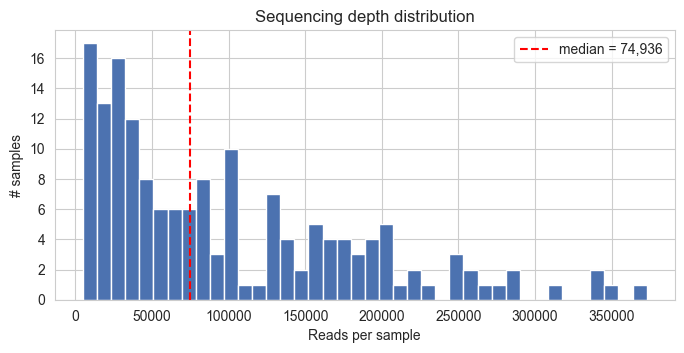

In [163]:
print(f"Depth: min={int(depths.min())}, median={int(depths.median())}, max={int(depths.max())}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(depths, bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(depths.median(), color="red", linestyle="--",
           label=f"median = {int(depths.median()):,}")
ax.set_xlabel("Reads per sample")
ax.set_ylabel("# samples")
ax.set_title("Sequencing depth distribution")
ax.legend()
plt.show()

**Each sample was sequenced to a different depth. Total reads per sample range from 5000 to 370000. Without normalization, deeper samples will look more diverse even if they are not actually.**

## 7) Alpha Diversity (via rarefaction and Mann-Whitney U-tests)

In [167]:
# Setting the minimum reads threshold

min_depth = 4500
low_depth_samples = depths[depths < min_depth]
print(f"Number of samples below {min_depth} reads:")
print(len(low_depth_samples))

Number of samples below 4500 reads:
0


In [168]:
# Keeping only samples with enough reads

good_samples = depths[depths >= min_depth].index

feature_table_for_alpha = feature_table_cleaned[good_samples].copy()

metadata_for_alpha = metadata_cleaned[metadata_cleaned["sample-id"].isin(good_samples)].copy()

In [169]:
# Transposing the tables to match scikit-bio alpha diversity code input style

feature_table_transposed = feature_table_for_alpha.T

feature_table_transposed = feature_table_transposed.astype(int)

display(feature_table_transposed.head())

feature_id,050086286d41bd135dfb39c9ef80bc8f,8aa05f21ee8c270308eae6edf572a1ab,c9383b2d3f400e2f4236fe54a5d738e6,f1d38f04e570af5dbdaf9903a9915e3f,8ff87e569cf1f5dd945145c0e433338f,04b511e2f8ab43657246f749ca05ec3b,675a0962f1197511dde4ff1172f15cf5,713bd9f74600877e29758d167ee23809,5f6b715d4e3ef710209c96a436c491b0,90f5a17f2ba978acd0e72f9ee18ef490,...,17f1e9f54d5d9e4b5d24cad7c16d138a,6b024fe58b57fb2b69c8dcd5196dd3eb,4460889ac1c35b96c1b049982ecc659a,8b6f3a6d7315ceffa633ae88c2feb8a0,9e23e49bcd4751a39374eeef161fe7ef,71ff0e930442543103d7f50da30ff0aa,e84e3768b45cbc235c5e3dfbc85b2a7f,52b5b8255896a82cd3ebb90a647e1cdc,f587c1b971867e43bf83d2958a966d66,dd6efc7d6e91db809faa41a1c99d6c69
DRA190110-002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DRA190110-004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DRA190110-006,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DRA190110-007,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DRA190110-008,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**One of the methods for Alpha Diversity used in the paper was rarefaction. That's the one I found easier to replicate. So, I also rarefied our data to the minimum depth of 5000 reads. After rarefaction, every sample has the same sequencing depth, so alpha diversity comparisons are fairer.**

In [170]:
np.random.seed(42)

rarefied_data_rows = []

for sample_id in feature_table_transposed.index:
    
    sample_counts = feature_table_transposed.loc[sample_id]

    rarefied_counts = subsample_counts(sample_counts.values, min_depth)
    
    rarefied_data = pd.Series(
        data = rarefied_counts,
        index = feature_table_transposed.columns,
        name = sample_id
    )

    rarefied_data_rows.append(rarefied_data)

rarefied_table = pd.DataFrame(rarefied_data_rows)

print("Rarefied table shape:")
print(rarefied_table.shape)

print("\nCheck rarefied depths:")
print(rarefied_table.sum(axis=1).describe())

display(rarefied_table.head())

Rarefied table shape:
(163, 2548)

Check rarefied depths:
count     163.0
mean     4500.0
std         0.0
min      4500.0
25%      4500.0
50%      4500.0
75%      4500.0
max      4500.0
dtype: float64


feature_id,050086286d41bd135dfb39c9ef80bc8f,8aa05f21ee8c270308eae6edf572a1ab,c9383b2d3f400e2f4236fe54a5d738e6,f1d38f04e570af5dbdaf9903a9915e3f,8ff87e569cf1f5dd945145c0e433338f,04b511e2f8ab43657246f749ca05ec3b,675a0962f1197511dde4ff1172f15cf5,713bd9f74600877e29758d167ee23809,5f6b715d4e3ef710209c96a436c491b0,90f5a17f2ba978acd0e72f9ee18ef490,...,17f1e9f54d5d9e4b5d24cad7c16d138a,6b024fe58b57fb2b69c8dcd5196dd3eb,4460889ac1c35b96c1b049982ecc659a,8b6f3a6d7315ceffa633ae88c2feb8a0,9e23e49bcd4751a39374eeef161fe7ef,71ff0e930442543103d7f50da30ff0aa,e84e3768b45cbc235c5e3dfbc85b2a7f,52b5b8255896a82cd3ebb90a647e1cdc,f587c1b971867e43bf83d2958a966d66,dd6efc7d6e91db809faa41a1c99d6c69
DRA190110-002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DRA190110-004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DRA190110-006,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DRA190110-007,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DRA190110-008,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [171]:
# Calculating the metrics

observed_asvs = alpha_diversity(
    metric = "observed_otus",
    counts = rarefied_table.values,
    ids = rarefied_table.index
)

shannon = alpha_diversity(
    metric = "shannon",
    counts = rarefied_table.values,
    ids = rarefied_table.index
)

simpson = alpha_diversity(
    metric = "simpson",
    counts = rarefied_table.values,
    ids = rarefied_table.index
)

pielou = alpha_diversity(
    metric = "pielou_e",
    counts = rarefied_table.values,
    ids = rarefied_table.index
)

In [172]:
alpha_df = pd.DataFrame({
    "sample-id": rarefied_table.index,
    "observed_asvs": observed_asvs,
    "shannon": shannon,
    "simpson": simpson,
    "pielou": pielou
})

In [173]:
alpha_df = alpha_df.merge(
    metadata_for_alpha,
    on = "sample-id",
    how = "left"
)

print("Alpha diversity table with metadata:")
print(alpha_df.shape)

display(alpha_df.head())

Alpha diversity table with metadata:
(163, 24)


,sample-id,observed_asvs,shannon,simpson,pielou,IMR quality control,voucher image,species,stage,morph,...,site_name,latitude,longitude,host_plant,temp_degF,relative_humidity,windspeed_mph,D_ng_ul,A260_280,Adjusted for sequencing conc.
0,DRA190110-002,54,2.924613,0.915813,0.733172,passed,FALSE,Jhae,adult,SW,...,Tamarac,26.188383,-80.172008,GRT,68.1,20.8,2.6,220.64,2.17,diluted to 173.0
1,DRA190110-004,4,0.009725,0.002220,0.007015,passed,FALSE,Jhae,adult,SW,...,Tamarac,26.188383,-80.172008,GRT,68.1,20.8,2.6,155.80,2.19,Yes
2,DRA190110-006,7,1.054159,0.614811,0.541731,passed,TRUE,Jhae,adult,SW,...,Tamarac,26.188383,-80.172008,GRT,68.1,20.8,2.6,28.20,2.28,Yes
3,DRA190110-007,17,0.113044,0.036345,0.039900,passed,TRUE,Jhae,adult,LW,...,Tamarac,26.188383,-80.172008,GRT,68.1,20.8,2.6,77.12,2.18,Yes
4,DRA190110-008,10,0.724778,0.504198,0.314767,passed,TRUE,Jhae,adult,LW,...,Tamarac,26.188383,-80.172008,GRT,68.1,20.8,2.6,1128.55,2.18,diluted to 182.5


In [174]:
# Descriptive summary of alpha diversity metrics

alpha_metrics = ["observed_asvs", "shannon", "simpson", "pielou"]

alpha_summary = alpha_df[alpha_metrics].describe()

display(alpha_summary)

,observed_asvs,shannon,simpson,pielou
count,163.000000,163.000000,163.000000,163.000000
mean,24.815951,0.808631,0.354217,0.268417
std,24.226615,0.701735,0.268369,0.185181
min,3.000000,0.009725,0.002220,0.007015
25%,9.000000,0.292735,0.124294,0.121106
50%,15.000000,0.632303,0.290429,0.228324
75%,32.000000,1.067277,0.545696,0.416174
max,134.000000,3.068323,0.932232,0.735036


### Interpretation:
The median for ASV is 15, meaning half of the samples had fewer than 15 ASVs and half had more than 15 ASVs. But the mean is 25.7, which is much higher than the median, which may mean that the distribution is right-skewed. Most bugs have a modest number of bacterial ASVs, but a smaller number of bugs have very high richness, pulling the average upward. It is further confirmed by the maximum ASV value being 138. That means some individual bugs had much more taxonomically rich microbiomes than the majority of samples. <br>
For shannon, a median of 0.632 suggests that many samples are not highly diverse. <br>
The median Simpson value is 0.291, which is very low. This may mean that many samples are probably dominated by one or a few bacterial ASVs, which supports the shannon result. <br>
The median Pielou value is 0.219, which is low. Even when a sample has multiple ASVs, those ASVs are usually not equally abundant. A few bacterial types dominate. 

Found something on Internet: This situation resembles the endosymbiont-dominated insect microbiome, in which most reads in most samples come from one or two highly abundant bacterial associates rather than from a diverse environmental community.

### 7.1 Wing Morphology

In [175]:
print("Species counts:")
print(alpha_df["species"].value_counts())

Species counts:
species
Jhae    161
Btri      2
Name: count, dtype: int64


In [176]:
jhae_alpha = alpha_df[(alpha_df["species"]=="Jhae") & (alpha_df["morph"].isin(["LW","SW"]))].copy()

alpha_metrics = ["observed_asvs", "shannon", "simpson", "pielou"]

for metric in alpha_metrics:
    
    lw_values = jhae_alpha.loc[jhae_alpha["morph"] == "LW", metric].dropna()
    sw_values = jhae_alpha.loc[jhae_alpha["morph"] == "SW", metric].dropna()
    
    test_result = stats.mannwhitneyu(
        lw_values,
        sw_values,
        alternative="two-sided"
    )
    
    p_value = test_result.pvalue
    
    print("----------------------------------")
    print("Metric:", metric)
    print("LW sample size:", len(lw_values))
    print("SW sample size:", len(sw_values))
    print("LW median:", round(lw_values.median(), 3))
    print("SW median:", round(sw_values.median(), 3))
    print("p-value:", round(p_value, 4))

----------------------------------
Metric: observed_asvs
LW sample size: 101
SW sample size: 45
LW median: 13.0
SW median: 19.0
p-value: 0.1236
----------------------------------
Metric: shannon
LW sample size: 101
SW sample size: 45
LW median: 0.603
SW median: 0.712
p-value: 0.3091
----------------------------------
Metric: simpson
LW sample size: 101
SW sample size: 45
LW median: 0.286
SW median: 0.329
p-value: 0.3111
----------------------------------
Metric: pielou
LW sample size: 101
SW sample size: 45
LW median: 0.221
SW median: 0.228
p-value: 0.4817


**It seems that Wing morph (long-wing vs short-wing) does not affect alpha diversity. Within J. haematoloma (LW n = 101, SW n = 45), Mann–Whitney U tests on all four alpha-diversity metrics returned no significant differences:**

/var/folders/yj/7196s0912vb7pv1x94mtgd_w0000gn/T/ipykernel_98986/471417438.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


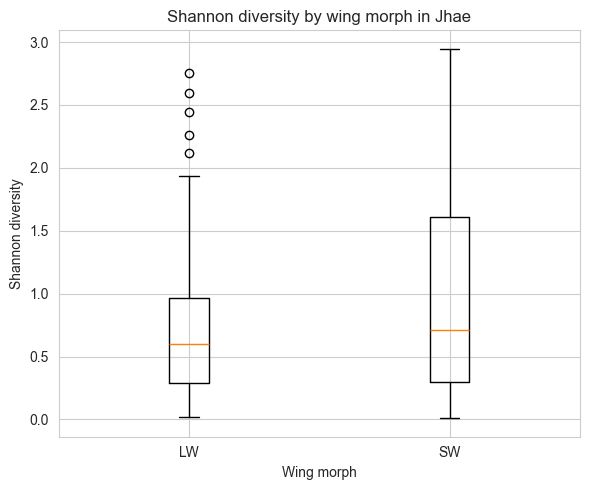

In [177]:
lw_shannon = jhae_alpha.loc[jhae_alpha["morph"] == "LW", "shannon"]
sw_shannon = jhae_alpha.loc[jhae_alpha["morph"] == "SW", "shannon"]

plt.figure(figsize=(6, 5))

plt.boxplot(
    [lw_shannon, sw_shannon],
    labels=["LW", "SW"]
)

plt.xlabel("Wing morph")
plt.ylabel("Shannon diversity")
plt.title("Shannon diversity by wing morph in Jhae")
plt.tight_layout()
plt.show()

/var/folders/yj/7196s0912vb7pv1x94mtgd_w0000gn/T/ipykernel_98986/217568461.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


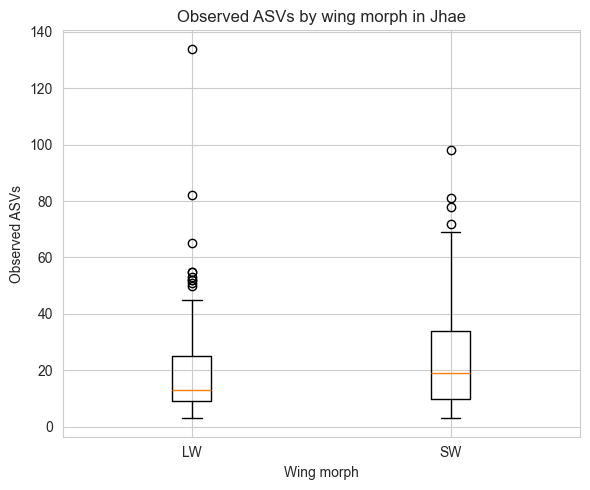

In [178]:
lw_observed = jhae_alpha.loc[jhae_alpha["morph"] == "LW", "observed_asvs"]
sw_observed = jhae_alpha.loc[jhae_alpha["morph"] == "SW", "observed_asvs"]

plt.figure(figsize=(6, 5))

plt.boxplot(
    [lw_observed, sw_observed],
    labels=["LW", "SW"]
)

plt.xlabel("Wing morph")
plt.ylabel("Observed ASVs")
plt.title("Observed ASVs by wing morph in Jhae")
plt.tight_layout()
plt.show()

### 7.2) Sex 

In [179]:
sex_alpha = jhae_alpha[
    alpha_df["sex"].isin(["m", "f"])
].copy()

sex_results = []

for metric in alpha_metrics:
    
    male_values = sex_alpha.loc[sex_alpha["sex"] == "m", metric].dropna()
    female_values = sex_alpha.loc[sex_alpha["sex"] == "f", metric].dropna()
    
    test_result = stats.mannwhitneyu(
        male_values,
        female_values,
        alternative="two-sided"
    )
    
    sex_results.append({
        "comparison": "male vs female",
        "metric": metric,
        "male_n": len(male_values),
        "female_n": len(female_values),
        "male_median": male_values.median(),
        "female_median": female_values.median(),
        "test": "Mann-Whitney U",
        "p_value": test_result.pvalue
    })

sex_results_df = pd.DataFrame(sex_results)

display(sex_results_df)

/var/folders/yj/7196s0912vb7pv1x94mtgd_w0000gn/T/ipykernel_98986/3594031132.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sex_alpha = jhae_alpha[


,comparison,metric,male_n,female_n,male_median,female_median,test,p_value
0,male vs female,observed_asvs,72,71,16.500000,12.000000,Mann-Whitney U,0.052433
1,male vs female,shannon,72,71,0.633754,0.567365,Mann-Whitney U,0.468615
2,male vs female,simpson,72,71,0.307915,0.285856,Mann-Whitney U,0.559610
3,male vs female,pielou,72,71,0.224925,0.228324,Mann-Whitney U,0.863756


/var/folders/yj/7196s0912vb7pv1x94mtgd_w0000gn/T/ipykernel_98986/3044643214.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


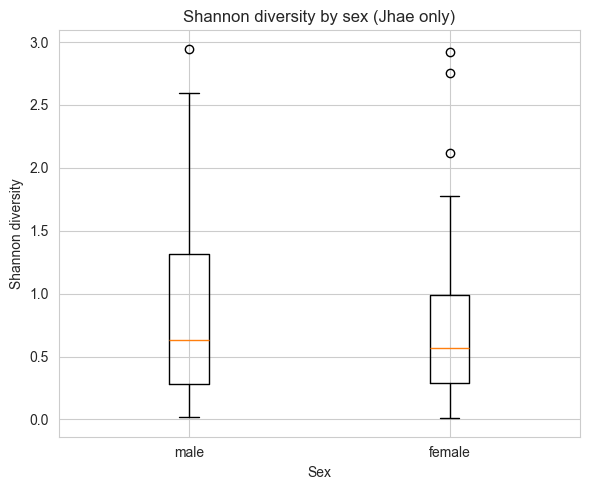

In [180]:
male_shannon = sex_alpha.loc[sex_alpha["sex"] == "m", "shannon"]
female_shannon = sex_alpha.loc[sex_alpha["sex"] == "f", "shannon"]

plt.figure(figsize=(6, 5))

plt.boxplot(
    [male_shannon, female_shannon],
    labels=["male", "female"]
)

plt.xlabel("Sex")
plt.ylabel("Shannon diversity")
plt.title("Shannon diversity by sex (Jhae only)")
plt.tight_layout()
plt.show()

### 7.3) Host Plant

In [181]:
host_alpha = jhae_alpha.dropna(subset=["host_plant"]).copy()

host_alpha["host_simple"] = host_alpha["host_plant"].apply(
    lambda x: "GRT" if x == "GRT" else "non-GRT"
)

print("Host group counts (Jhae only, after dropping NaN):")
print(host_alpha["host_simple"].value_counts())

Host group counts (Jhae only, after dropping NaN):
host_simple
GRT        142
non-GRT      4
Name: count, dtype: int64


In [182]:
host_results = []

for metric in alpha_metrics:
    grt_values     = host_alpha.loc[host_alpha["host_simple"] == "GRT",     metric].dropna()
    non_grt_values = host_alpha.loc[host_alpha["host_simple"] == "non-GRT", metric].dropna()

    test_result = stats.mannwhitneyu(
        grt_values,
        non_grt_values,
        alternative="two-sided"
    )

    host_results.append({
        "metric": metric,
        "GRT_n":         len(grt_values),
        "non_GRT_n":     len(non_grt_values),
        "GRT_median":    grt_values.median(),
        "non_GRT_median": non_grt_values.median(),
        "p_value":       test_result.pvalue,
    })

host_results_df = pd.DataFrame(host_results)
display(host_results_df)

,metric,GRT_n,non_GRT_n,GRT_median,non_GRT_median,p_value
0,observed_asvs,142,4,13.500000,31.500000,0.050501
1,shannon,142,4,0.606127,1.624606,0.005266
2,simpson,142,4,0.287019,0.752878,0.001051
3,pielou,142,4,0.220086,0.476209,0.015218


*Clarification: Here, non-GRT group has only 4 samples, which is very low and overall very imbalanced in comparison to the whole dataset.*

/var/folders/yj/7196s0912vb7pv1x94mtgd_w0000gn/T/ipykernel_98986/244986178.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


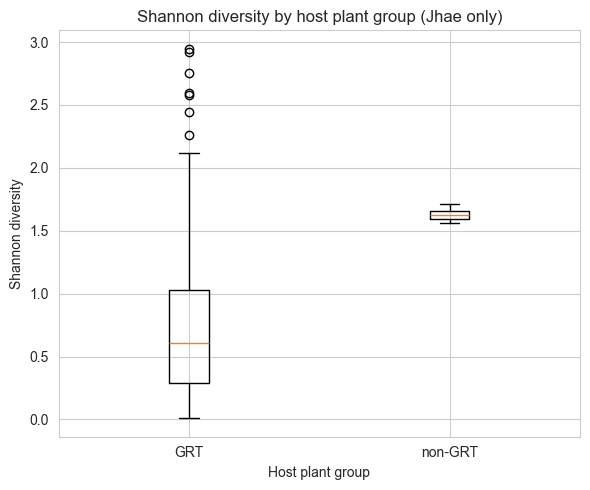

In [183]:
grt_shannon = host_alpha.loc[host_alpha["host_simple"] == "GRT", "shannon"]
non_grt_shannon = host_alpha.loc[host_alpha["host_simple"] == "non-GRT", "shannon"]

plt.figure(figsize=(6, 5))

plt.boxplot(
    [grt_shannon, non_grt_shannon],
    labels=["GRT", "non-GRT"]
)

plt.xlabel("Host plant group")
plt.ylabel("Shannon diversity")
plt.title("Shannon diversity by host plant group (Jhae only)")
plt.tight_layout()
plt.show()

### 7.4) Species
Clarification: Btri (n=2) is reported descriptively only. No statistical test is run because the sample size is far too small to estimate a within-group distribution.

observed_asvs                 shannon                      simpson  \
                count median min  max   count median    min    max   count   
species                                                                      
Btri                2   10.0   8   12       2  0.879  0.835  0.922       2   
Jhae              161   16.0   3  134     161  0.619  0.010  3.068     161   

                             pielou                       
        median    min    max  count median    min    max  
species                                                   
Btri     0.498  0.475  0.521      2  0.390  0.336  0.444  
Jhae     0.290  0.002  0.932    161  0.228  0.007  0.735

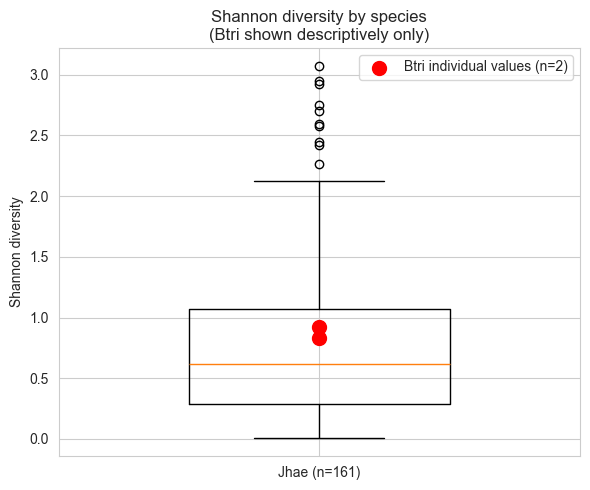

In [184]:
# Descriptive comparison only — no statistical test (Btri n=2)
species_summary = (alpha_df.groupby("species")[alpha_metrics]
                   .agg(["count", "median", "min", "max"])
                   .round(3))
display(species_summary)

fig, ax = plt.subplots(figsize=(6, 5))

jhae_values = alpha_df.loc[alpha_df["species"] == "Jhae", "shannon"]
btri_values = alpha_df.loc[alpha_df["species"] == "Btri", "shannon"]

ax.boxplot([jhae_values], tick_labels=["Jhae (n=161)"], widths=0.5)
ax.scatter([1] * len(btri_values), btri_values,
           color="red", s=100, zorder=5,
           label=f"Btri individual values (n={len(btri_values)})")
ax.set_ylabel("Shannon diversity")
ax.set_title("Shannon diversity by species\n(Btri shown descriptively only)")
ax.legend()
plt.tight_layout()
plt.show()

### 7.5) Cities

In [185]:
print("City counts:")
print(alpha_df["city"].value_counts())

City counts:
city
Lake Wales FL           31
Lake Alfred FL          24
Lakeland FL             22
Fort Lauderdale FL      18
Delrey Beach FL         18
Delray Beach FL          9
Bartow FL                9
Kendall Lakes FL         8
Lehigh Acres FL          7
Islamorada FL            4
Lake Bentley FL          3
Winter Haven FL          3
Miami-Dade County FL     2
Waterville ME            2
Key Largo FL             1
Name: count, dtype: int64


In [186]:
city_alpha = jhae_alpha.copy()
city_alpha["city"] = city_alpha["city"].replace({"Delrey Beach FL": "Delray Beach FL"})

print(city_alpha["city"].value_counts())

city
Lake Wales FL         29
Delray Beach FL       26
Lake Alfred FL        21
Lakeland FL           20
Fort Lauderdale FL    18
Bartow FL              9
Lehigh Acres FL        7
Kendall Lakes FL       6
Islamorada FL          4
Lake Bentley FL        3
Winter Haven FL        3
Name: count, dtype: int64


In [187]:
city_sizes = city_alpha["city"].value_counts()
cities_to_keep = city_sizes[city_sizes >= 5].index.tolist() # Dropping cities with fewer than 5 samples 
city_alpha = city_alpha[city_alpha["city"].isin(cities_to_keep)].copy()

print(city_alpha["city"].value_counts())

city_results = []

for metric in alpha_metrics:
    groups_for_test = []
    group_names = []

    for city_name in cities_to_keep:
        values = city_alpha.loc[city_alpha["city"] == city_name, metric].dropna()
        groups_for_test.append(values)
        group_names.append(city_name)

    test_result = stats.kruskal(*groups_for_test)

    city_results.append({
        "metric":  metric,
        "n_cities": len(cities_to_keep),
        "H_stat":  test_result.statistic,
        "p_value": test_result.pvalue,
    })

city_results_df = pd.DataFrame(city_results)
display(city_results_df)

city
Lake Wales FL         29
Delray Beach FL       26
Lake Alfred FL        21
Lakeland FL           20
Fort Lauderdale FL    18
Bartow FL              9
Lehigh Acres FL        7
Kendall Lakes FL       6
Name: count, dtype: int64


,metric,n_cities,H_stat,p_value
0,observed_asvs,8,15.864310,0.026385
1,shannon,8,12.695004,0.079898
2,simpson,8,11.030044,0.137314
3,pielou,8,9.675427,0.207725


/var/folders/yj/7196s0912vb7pv1x94mtgd_w0000gn/T/ipykernel_98986/969506458.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


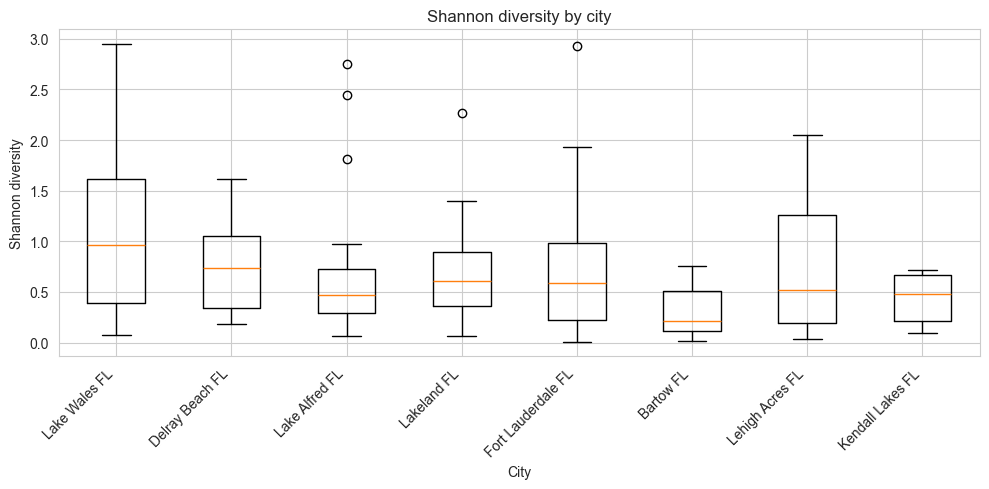

In [188]:
groups = []
labels = []

for city_name in cities_to_keep:
    values = city_alpha.loc[
        city_alpha["city"] == city_name,
        "shannon"
    ].dropna()
    
    groups.append(values)
    labels.append(city_name)

plt.figure(figsize=(10, 5))

plt.boxplot(groups, labels=labels)

plt.xlabel("City")
plt.ylabel("Shannon diversity")
plt.title("Shannon diversity by city")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8) Taxonomic Compostion (Relative Abundance)

##### Alpha diversity showed how many taxa each sample contai. Now, relative abundance (the fraction of that sample's reads belonging to each taxon) will tell us which taxa dominate. We summarize at two levels: Phylum and Genus. For each sample we convert raw read counts to relative abundance. Relative abundance removes the sequencing-depth bias since every sample now sums to 1, so they're directly comparable for composition.

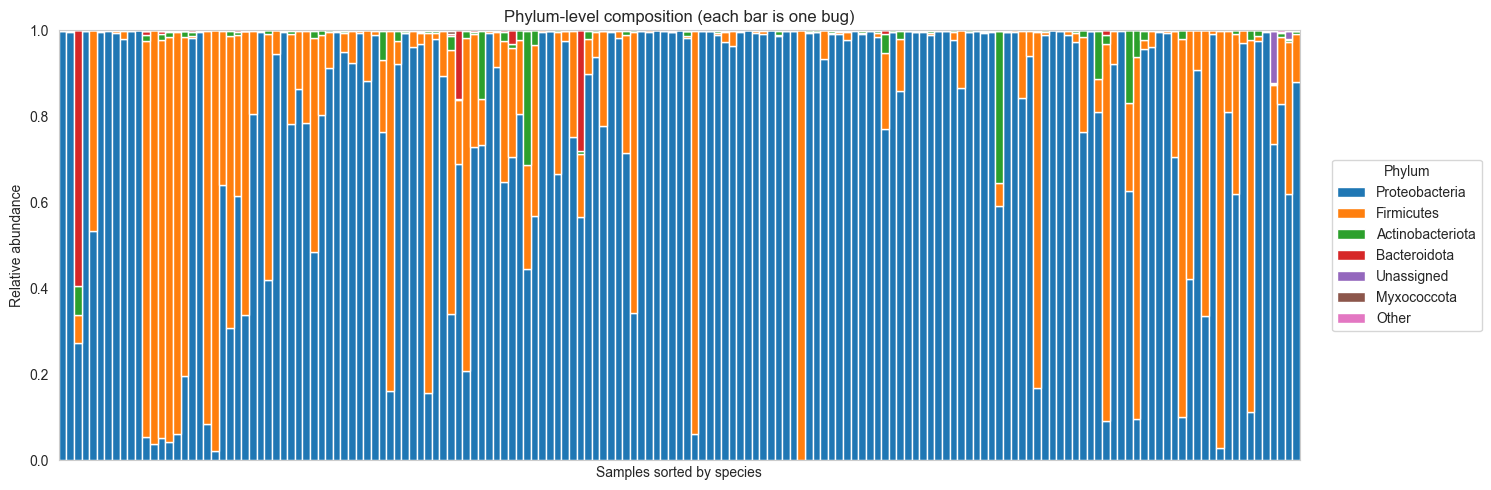


Mean relative abundance of top phyla:
phylum
Proteobacteria      78.46
Firmicutes          19.47
Actinobacteriota     1.24
Bacteroidota         0.72
Unassigned           0.09
Myxococcota          0.01
dtype: float64


In [191]:
#Linking each ASV's reads to its phylum ----
feature_long = (feature_table_cleaned
                .reset_index()
                .melt(id_vars = "feature_id", var_name = "sample-id", value_name = "reads")
                .merge(taxonomy_cleaned[["feature_id", "phylum"]], on = "feature_id"))

# Replacing missing phylum names
feature_long["phylum"] = feature_long["phylum"].fillna("Unassigned")

# Sum reads for each phylum per sample
phylum_counts = (feature_long
                 .groupby(["sample-id", "phylum"])["reads"]
                 .sum()
                 .unstack(fill_value = 0))           
phylum_rel_abundance = phylum_counts.div(phylum_counts.sum(axis = 1), axis = 0)

# Keep the top 6 most abundant phyla while the rest falls into 'other'
top_phyla = phylum_rel_abundance.mean().sort_values(ascending = False).head(6).index.tolist()
phylum_to_plot = phylum_rel_abundance[top_phyla].copy()
phylum_to_plot["Other"] = 1 - phylum_to_plot.sum(axis = 1)

# Sorting
sample_order = metadata_cleaned.sort_values(["species", "sample-id"])["sample-id"].tolist()
phylum_to_plot = phylum_to_plot.loc[sample_order]

# Bar plot 
fig, ax = plt.subplots(figsize=(15, 5))
colors = sns.color_palette("tab10", n_colors=len(phylum_to_plot.columns))

bottom = np.zeros(len(phylum_to_plot))
for i, phylum_name in enumerate(phylum_to_plot.columns):
    ax.bar(range(len(phylum_to_plot)), phylum_to_plot[phylum_name],
           bottom = bottom, color = colors[i], label = phylum_name, width = 1.0)
    bottom = bottom + phylum_to_plot[phylum_name].values

ax.set_xlim(-0.5, len(phylum_to_plot) - 0.5)
ax.set_ylim(0, 1)
ax.set_xlabel("Samples sorted by species")
ax.set_ylabel("Relative abundance")
ax.set_title("Phylum-level composition (each bar is one bug)")
ax.set_xticks([])
ax.legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), title = "Phylum")
plt.tight_layout()
plt.show()

print("\nMean relative abundance of top phyla:")
print((phylum_rel_abundance.mean().sort_values(ascending=False).head(6) * 100).round(2))

**Interpretation.** Two phyla dominate every sample, which are **Proteobacteria** and **Firmicutes**. Together they account for around 97% of all bacterial reads in the dataset. Actinobacteriota and Bacteroidota appear as minor contributors,
and nothing else exceeds 0.1% on average. 

Visually, we can see substantial variation in the Proteobacteria/Firmicutes balance across individuals--- some samples are nearly pure Proteobacteria (blue), others contain a large Firmicutes (orange) fraction.

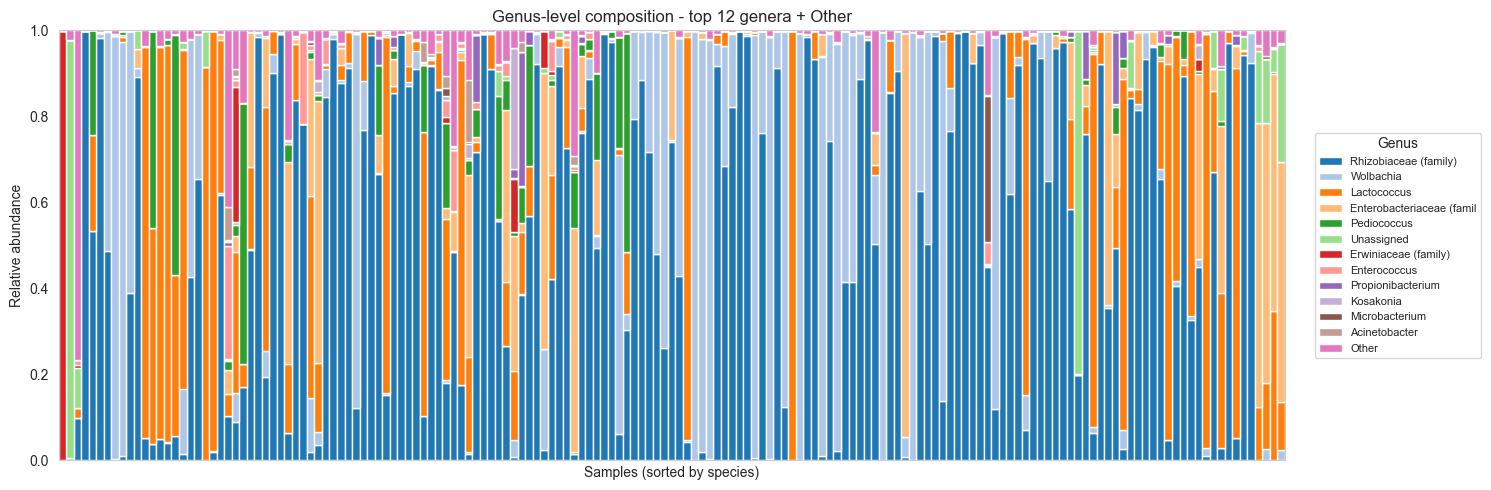

In [192]:
# same plot at the genus level

feature_long_genus = (feature_table_cleaned
                      .reset_index()
                      .melt(id_vars="feature_id", var_name = "sample-id", value_name = "reads")
                      .merge(taxonomy_cleaned[["feature_id", "genus_label"]], on = "feature_id"))

genus_counts        = (feature_long_genus
                       .groupby(["genus_label", "sample-id"])["reads"]
                       .sum()
                       .unstack(fill_value = 0))    
genus_rel_abundance = genus_counts.div(genus_counts.sum(axis = 0), axis = 1)

# Top 12 genera
top_genera   = genus_rel_abundance.mean(axis = 1).sort_values(ascending = False).head(12).index.tolist()
genus_to_plot = genus_rel_abundance.loc[top_genera, sample_order].T.copy()
genus_to_plot["Other"] = 1 - genus_to_plot.sum(axis = 1)

# Bar plot
fig, ax = plt.subplots(figsize=(15, 5))
colors = sns.color_palette("tab20", n_colors = len(genus_to_plot.columns))
bottom = np.zeros(len(genus_to_plot))
for i, genus_name in enumerate(genus_to_plot.columns):
    ax.bar(range(len(genus_to_plot)), genus_to_plot[genus_name],
           bottom = bottom, color = colors[i],
           label  = genus_name[:25], width = 1.0)
    bottom = bottom + genus_to_plot[genus_name].values
    
ax.set_xlim(-0.5, len(genus_to_plot) - 0.5)
ax.set_ylim(0, 1)
ax.set_xlabel("Samples (sorted by species)")
ax.set_ylabel("Relative abundance")
ax.set_title("Genus-level composition - top 12 genera + Other")
ax.set_xticks([])
ax.legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), title = "Genus", fontsize = 8)
plt.tight_layout()
plt.show()

In [193]:
print("\nMean relative abundance of top genera:")
print((genus_rel_abundance.mean(axis=1).sort_values(ascending=False).head(10) * 100).round(2))


Mean relative abundance of top genera:
genus_label
Rhizobiaceae (family)          50.77
Wolbachia                      16.14
Lactococcus                    15.32
Enterobacteriaceae (family)     6.98
Pediococcus                     3.01
Unassigned                      1.94
Erwiniaceae (family)            0.98
Enterococcus                    0.66
Propionibacterium               0.64
Kosakonia                       0.25
dtype: float64


**Interpretation. The Rhizobiaceae family is the single dominant microbe, with Wolbachia and Lactococcus as the next most dominant and Enterobacteriaceae family being slightly prevalent as well. These four groups alone account for around 90% of reads on average. The composition difference is very visible in the plot: some samples are almost pure Rhizobiaceae, others are dominated by Lactococcus or Enterobacteriaceae.**

## 9) Core Microbiome in Jhae

Two metrics matter: 
- Prevalence: fraction of samples where the genus is present (reads > 0).
- Mean abundance: average relative abundance across samples.

A taxon that is both prevalent (in most bugs) and abundant (a substantial fraction of those bugs' reads) is the strongest candidate for a symbiont. I used a 50% prevalence threshold as the cut-off. 

In [194]:
jhae_sample_ids = metadata_cleaned.loc[metadata_cleaned["species"] == "Jhae",
                                       "sample-id"].tolist()
genus_jhae = genus_rel_abundance[jhae_sample_ids]

prevalence     = (genus_jhae > 0).mean(axis = 1)
mean_abundance = genus_jhae.mean(axis = 1)

core_df = pd.DataFrame({
    "prevalence":     prevalence,
    "mean_abundance": mean_abundance,
}).sort_values("mean_abundance", ascending=False)

# core threshold >=50% prevalence
core_taxa = core_df[core_df["prevalence"] >= 0.50]
print(f"Number of core genera (prevalence >= 50%): {len(core_taxa)}")
print("\nCore taxa table:")
display(core_taxa.round(3))

Number of core genera (prevalence >= 50%): 10

Core taxa table:


,prevalence,mean_abundance
genus_label,,
Rhizobiaceae (family),0.975,0.514
Wolbachia,0.888,0.163
Lactococcus,0.882,0.155
Enterobacteriaceae (family),0.720,0.071
Pediococcus,0.547,0.030
Unassigned,0.584,0.014
Cutibacterium,0.826,0.001
Methylobacterium-Methylorubrum,0.702,0.001
uncultured,0.596,0.001


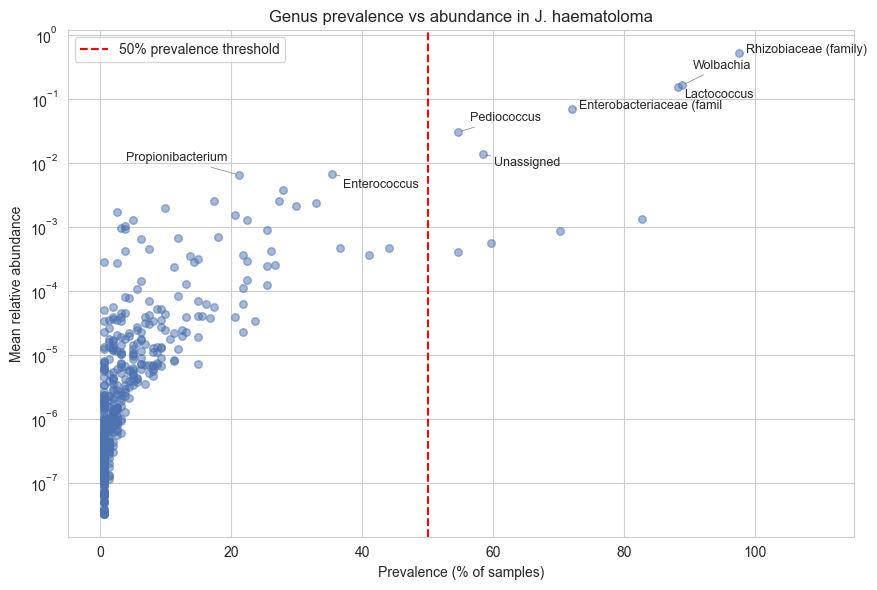

In [195]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(core_df["prevalence"] * 100, core_df["mean_abundance"],
           color="#4C72B0", alpha = 0.5, s = 30)


label_offsets = {
    "Rhizobiaceae": (8, 0),
    "Wolbachia": (8, 12),  
    "Lactococcus": (4, -8),  
    "Enterobacteriaceae": (8, -5),
    "Pediococcus": (8, 8),
    "Unassigned": (8, -8),
    "Propionibacterium": (-8, 10),   
    "Enterococcus": (8, -10),  
}

for genus_name, row in core_df.head(8).iterrows():
    dx, dy = label_offsets.get(genus_name, (5, 0))
    ax.annotate(genus_name[:25],
                xy = (row["prevalence"] * 100, row["mean_abundance"]),
                xytext = (dx, dy), textcoords = "offset points",
                fontsize = 9,
                ha = "left" if dx >= 0 else "right",
                arrowprops = dict(arrowstyle = "-", color = "gray", lw = 0.5,
                                shrinkA = 0, shrinkB = 2))

ax.axvline(50, color = "red", linestyle = "--", label = "50% prevalence threshold")
ax.set_xlabel("Prevalence (% of samples)")
ax.set_ylabel("Mean relative abundance")
ax.set_yscale("log")
ax.set_xlim(-5, 115)                       
ax.set_title("Genus prevalence vs abundance in J. haematoloma")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The J. haematoloma gut has a small core microbiota. Just **10 genera** pass the 50% prevalence threshold, and four **(Rhizobiaceae (family), Wolbachia, Lactococcus, Enterobacteriaceae (family))** are dramatically more abundant than the rest.


## 10) Taxa Prevlance in BV Plants:

#### In the alpha-diversity section, I found that the 4 Jhae collected from non-GRT host plants (balloon vine, BV) had substantially higher Shannon and Simpson diversity than the 142 bugs from goldenrain tree (GRT). Here, I tried to answer what microbes drive that difference. Are the same core taxa present, or there is significant difference?                           I identified which genera differ in prevalence and mean abundance between the two host-plant groups, at the descriptive level.

In [196]:
grt_sample_ids    = metadata_cleaned.loc[
    (metadata_cleaned["species"] == "Jhae") & (metadata_cleaned["host_plant"] == "GRT"),
    "sample-id"].tolist()
nonGRT_sample_ids = metadata_cleaned.loc[
    (metadata_cleaned["species"] == "Jhae")
    & (metadata_cleaned["host_plant"].notna())
    & (metadata_cleaned["host_plant"] != "GRT"),
    "sample-id"].tolist()

print(f"GRT samples:     {len(grt_sample_ids)}")
print(f"BV samples: {len(nonGRT_sample_ids)}")

host_split = pd.DataFrame({
    "GRT_prevalence":      (genus_rel_abundance[grt_sample_ids]    > 0).mean(axis=1),
    "GRT_mean":            genus_rel_abundance[grt_sample_ids].mean(axis=1),
    "BV_prevalence":   (genus_rel_abundance[nonGRT_sample_ids] > 0).mean(axis=1),
    "BV_mean":         genus_rel_abundance[nonGRT_sample_ids].mean(axis=1),
})

top_for_table = host_split.loc[core_df.head(10).index].round(3)
print("\nPrevalence and mean abundance by host plant - top 10 genera:")
display(top_for_table)

GRT samples:     154
BV samples: 5

Prevalence and mean abundance by host plant - top 10 genera:


,GRT_prevalence,GRT_mean,BV_prevalence,BV_mean
genus_label,,,,
Rhizobiaceae (family),0.994,0.530,0.4,0.010
Wolbachia,0.896,0.170,0.6,0.010
Lactococcus,0.877,0.146,1.0,0.329
Enterobacteriaceae (family),0.714,0.058,0.8,0.475
Pediococcus,0.545,0.032,0.4,0.002
Unassigned,0.578,0.010,0.8,0.129
Enterococcus,0.344,0.007,0.4,0.003
Propionibacterium,0.214,0.007,0.0,0.000
Erwiniaceae (family),0.286,0.004,0.2,0.000


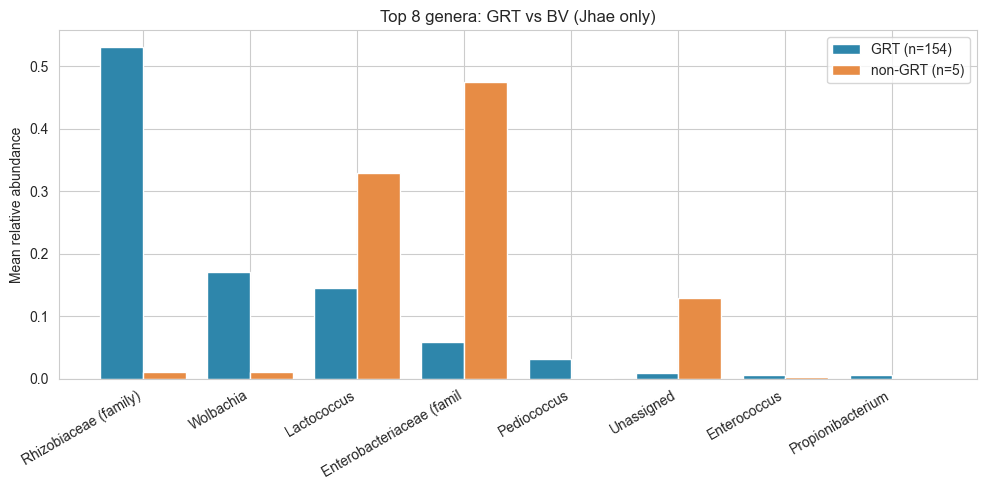

In [197]:
top_8 = core_df.head(8).index.tolist()
plot_df = host_split.loc[top_8, ["GRT_mean", "BV_mean"]].copy()

fig, ax = plt.subplots(figsize=(10, 5))
x_positions = np.arange(len(top_8))
bar_width = 0.4
ax.bar(x_positions - bar_width/2, plot_df["GRT_mean"],    bar_width,
       label=f"GRT (n={len(grt_sample_ids)})",    color="#2E86AB")
ax.bar(x_positions + bar_width/2, plot_df["BV_mean"], bar_width,
       label=f"non-GRT (n={len(nonGRT_sample_ids)})", color="#E78C45")
ax.set_xticks(x_positions)
ax.set_xticklabels([g[:25] for g in top_8], rotation=30, ha="right")
ax.set_ylabel("Mean relative abundance")
ax.set_title("Top 8 genera: GRT vs BV (Jhae only)")
ax.legend()
plt.tight_layout()
plt.show() 

**Interpretation:** The BV samples look biologically very different from GRT samples.

Rhizobiaceae (the dominant symbiont on GRT) drops to around 1% in non-GRT bugs, and its prevalence falls from 99% to 40%.
Wolbachia drops in both abundance and prevalence significantly as well. 
On the other hand, Enterobacteriaceae increases from 6% to 48% — it becomes the dominant taxon in BV bugs. Lactococcus also jumps from 15% to 33% and reaches 100% prevalence.

It seems that the BV samples don't just have more diverse microbiomes (as we saw from Shannon/Simpson), they show a complete reorganization of the core community. The GRT-associated symbionts are rather suppressed. 

## 11) Beta Diversity 

**Alpha diversity asked how diverse is each sample. Beta diversity asks how different are samples from each other. Two samples may have identical Shannon indices and yet contain completely different bacteria, so alpha diversity alone is not enough to decide whether two groups have similar microbiomes.**

### 11.1) Bray Curtis

In [214]:
# Computing Bray-Curtis on the rarefied table (so all samples have equal depth)
bc = beta_diversity("braycurtis", rarefied_table.values, ids = rarefied_table.index)

ordination_result = pcoa(bc, number_of_dimensions=3)
pcoa_df = ordination_result.samples.copy()
pcoa_df.columns = ["PC1", "PC2", "PC3"]
pcoa_df["sample-id"] = pcoa_df.index
pcoa_df = pcoa_df.merge(metadata_cleaned, on="sample-id")

variance_explained = ordination_result.proportion_explained.values * 100
print(f"PC1 explains {variance_explained[0]:.1f}% of variance")
print(f"PC2 explains {variance_explained[1]:.1f}% of variance")
print(f"PC3 explains {variance_explained[2]:.1f}% of variance")
print(f"Total in 3D: {variance_explained[:3].sum():.1f}%")

PC1 explains 40.7% of variance
PC2 explains 26.4% of variance
PC3 explains 8.8% of variance
Total in 3D: 75.9%


### 11.2) PCoA

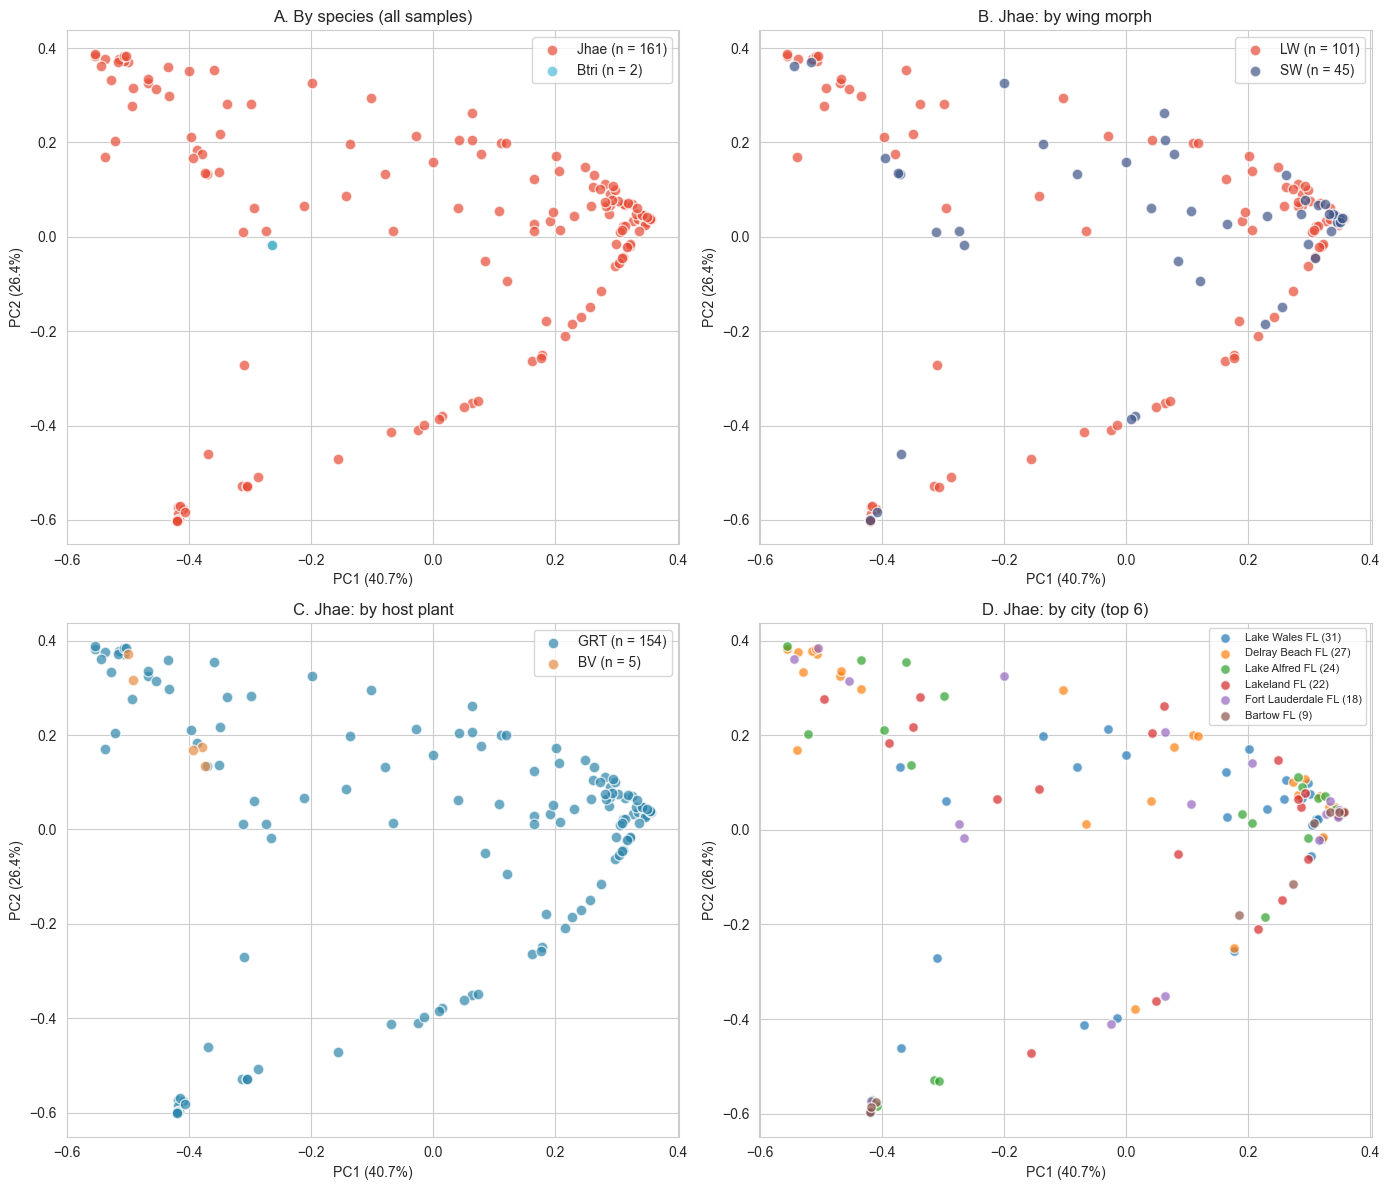

In [215]:
jhae_pcoa = pcoa_df[pcoa_df["species"] == "Jhae"].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# species (all samples--- to show the 2 Btri samples to confirm they aren't outliers
ax = axes[0, 0]
for sp, color in zip(["Jhae", "Btri"], ["#E64B35", "#4DBBD5"]):
    subset = pcoa_df[pcoa_df["species"] == sp]
    ax.scatter(subset["PC1"], subset["PC2"], color=color, s=60, alpha=0.7,
               edgecolor = "white", label = f"{sp} (n = {len(subset)})")
ax.set_title("A. By species (all samples)")
ax.legend()

# morph (Jhae only)
ax = axes[0, 1]
for morph, color in zip(["LW", "SW"], ["#E64B35", "#3C5488"]):
    subset = jhae_pcoa[jhae_pcoa["morph"] == morph]
    ax.scatter(subset["PC1"], subset["PC2"], color = color, s = 60, alpha = 0.7,
               edgecolor = "white", label = f"{morph} (n = {len(subset)})")
ax.set_title("B. Jhae: by wing morph")
ax.legend()

# host plant (Jhae only)
ax = axes[1, 0]
for plant, color in zip(["GRT", "BV"], ["#2E86AB", "#E78C45"]):
    subset = jhae_pcoa[jhae_pcoa["host_plant"] == plant]
    ax.scatter(subset["PC1"], subset["PC2"], color = color, s = 60, alpha = 0.7,
               edgecolor = "white", label = f"{plant} (n = {len(subset)})")
ax.set_title("C. Jhae: by host plant")
ax.legend()

# city 
ax = axes[1, 1]
city_for_pcoa = jhae_pcoa.copy()
city_for_pcoa["city"] = city_for_pcoa["city"].replace({"Delrey Beach FL": "Delray Beach FL"})
top_cities = city_for_pcoa["city"].value_counts().head(6).index.tolist()
palette = sns.color_palette("tab10", n_colors = len(top_cities))
for city, color in zip(top_cities, palette):
    subset = city_for_pcoa[city_for_pcoa["city"] == city]
    ax.scatter(subset["PC1"], subset["PC2"], color = color, s = 50, alpha = 0.7,
               edgecolor = "white", label = f"{city} ({len(subset)})")
ax.set_title("D. Jhae: by city (top 6)")
ax.legend(fontsize = 8)

for ax in axes.flat:
    ax.set_xlabel(f"PC1 ({variance_explained[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({variance_explained[1]:.1f}%)")

plt.tight_layout()
plt.show()

### 11.3) PERMANOVA (Jhae only)

PCoA showed us patterns visually. PERMANOVA (Permutational Multivariate Analysis Of Variance; tests whether those patterns are **statistically significant**.

My implementation of PERMANOVA has the following approach (based on my understanding of PERMANOVA): 

1. For a given grouping variable (e.g., morph), compute the average pairwise distance within groups and between groups.
2. Compute a pseudo-F statistic: a large F means between-group distances are much bigger than within-group distances (groups are well-separated).
3. Randomly shuffle the group labels 999 times. For each shuffle, recompute F. This gives a null distribution.
4. The p-value is the fraction of shuffles where the random F was as extreme as the real F.

It's non-parametric, meaning no assumption that the data is normally distributed. 
A small p-value tells us groups differ, but not how much. The R² (the fraction of variance explained by the grouping) tells us the effect size.

In [213]:
def run_permanova(distance_matrix, group_series):
    valid = group_series.dropna()
    valid = valid[valid.index.isin(distance_matrix.ids)]
    if valid.nunique() < 2 or valid.value_counts().min() < 3:
        return None

    sub_dm = distance_matrix.filter(valid.index)
    return permanova(sub_dm, valid.values, permutations=999)

jhae_dm = bc.filter(jhae_sample_ids)
metadata_indexed = metadata_cleaned.set_index("sample-id")
metadata_indexed["city"] = metadata_indexed["city"].replace({"Delrey Beach FL":"Delray Beach FL"})

print("PERMANOVA results (Jhae only, 999 permutations):\n")
print(f"{'Variable':12s}  {'F-stat':>8s}  {'p-value':>8s}  {'n':>5s}")
print("-" * 45)

for var in ["morph", "sex", "host_plant"]:   
    r = run_permanova(jhae_dm, metadata_indexed[var])
    if r is not None:
        print(f"{var:12s}  {r['test statistic']:>8.2f}  "
              f"{r['p-value']:>8.4f}  {int(r['sample size']):>5d}")
    else:
        print(f"{var:12s}  (skipped - insufficient group sizes)")

# filtering City because PERMANOVA can't meaningfully test groups of size 1-2, and several cities in our data have very few samples.

# Picking the cities that have at least 5 Jhae samples
jhae_city_counts = metadata_indexed.loc[jhae_sample_ids, "city"].value_counts()
cities_to_keep   = jhae_city_counts[jhae_city_counts >= 5].index.tolist()

# Keeping only the samples whose city is in that list
city_sample_ids = [s for s in jhae_sample_ids
                   if metadata_indexed.loc[s, "city"] in cities_to_keep]

#Running PERMANOVA on this filtered subset
city_dm  = bc.filter(city_sample_ids)
city_labels = metadata_indexed.loc[city_sample_ids, "city"].values
city_result = permanova(city_dm, city_labels, permutations=999)

print(f"{'city':12s}  {city_result['test statistic']:>8.2f}  "
      f"{city_result['p-value']:>8.4f}  {int(city_result['sample size']):>5d}"
      f"  ({len(cities_to_keep)} cities, n>=5 each)")

PERMANOVA results (Jhae only, 999 permutations):

Variable        F-stat   p-value      n
---------------------------------------------
morph             1.31    0.2310    146
sex               1.00    0.3610    147
host_plant        9.14    0.0010    159
city              2.10    0.0040    146  (8 cities, n>=5 each)


**Interpretation:** 
For Jhae,
1. Wing morph and sex don't structure the microbiome. This is confirmed both the alpha-diversity level (richness/evenness) and now at the
   beta-diversity level (composition). 
2. Host plant has a large effect(F=9.14 is high). This converges with
   the alpha-diversity signal and the descriptive prevalence-by-host result. The non-GRT bugs really do carry compositionally distinct
   microbiomes — but again, only n=5, so this requires more samples to confirm fully.
3. City has a significant effect (F=2.10, p=0.002). Samples from the same city are more similar to each other than to samples from other
   cities. 

## 12) Differential Abundance

In [229]:
jhae_sample_ids_all = metadata_cleaned.loc[metadata_cleaned["species"] == "Jhae", "sample-id"].tolist()

prevalence_across_jhae = (genus_rel_abundance[jhae_sample_ids_all] > 0).mean(axis=1)
testable_genera = prevalence_across_jhae[prevalence_across_jhae >= 0.10].index.tolist()

print(f"Testable genera: {len(testable_genera)}")

Testable genera: 60


### 12.1) Which Genera Differ between LW and SW?
#### For each genus with prevalence ≥10% (so the test isn't dominated by zeros), is its relative abundance different between LW and SW samples?

In [230]:
lw_sample_ids = metadata_cleaned.loc[
    (metadata_cleaned["species"] == "Jhae") & (metadata_cleaned["morph"] == "LW"),
    "sample-id"].tolist()
sw_sample_ids = metadata_cleaned.loc[
    (metadata_cleaned["species"] == "Jhae") & (metadata_cleaned["morph"] == "SW"),
    "sample-id"].tolist()

print(f"LW samples: {len(lw_sample_ids)},  SW samples: {len(sw_sample_ids)}")

# Restricted to prevalent genera (>=10%) 
print(f"Testing {len(testable_genera)} genera")

# Mann-Whitney U test per genus
morph_results = []
for genus_name in testable_genera:
    lw_values = genus_rel_abundance.loc[genus_name, lw_sample_ids].values
    sw_values = genus_rel_abundance.loc[genus_name, sw_sample_ids].values

    test_result = stats.mannwhitneyu(lw_values, sw_values, alternative = "two-sided")

    pseudocount = 1e-6
    log2_fc = np.log2((sw_values.mean() + pseudocount) / (lw_values.mean() + pseudocount))

    morph_results.append({
        "genus":   genus_name,
        "LW_mean": lw_values.mean(),
        "SW_mean": sw_values.mean(),
        "log2_FC_SW_over_LW": log2_fc,
        "p_value": test_result.pvalue,
    })

morph_da_df = pd.DataFrame(morph_results)
morph_da_df["q_value_BH"] = multipletests(morph_da_df["p_value"], method = "fdr_bh")[1]
morph_da_df = morph_da_df.sort_values("p_value")

print(f"\nGenera significant at q < 0.05: {(morph_da_df['q_value_BH'] < 0.05).sum()}")
print(f"Genera significant at q < 0.10: {(morph_da_df['q_value_BH'] < 0.10).sum()}")

print("\nTop 10 genera by p-value:")
display(morph_da_df.head(10).round(4))

LW samples: 101,  SW samples: 45
Testing 60 genera

Genera significant at q < 0.05: 0
Genera significant at q < 0.10: 0

Top 10 genera by p-value:


,genus,LW_mean,SW_mean,log2_FC_SW_over_LW,p_value,q_value_BH
54,Streptococcus,0.0000,0.0002,2.5218,0.0571,0.8115
53,Stenotrophomonas,0.0023,0.0010,-1.2118,0.0591,0.8115
4,Actinomyces,0.0001,0.0008,2.5615,0.0738,0.8115
52,Staphylococcus,0.0002,0.0010,2.4939,0.0951,0.8115
45,Pseudomonas,0.0001,0.0014,4.6463,0.0993,0.8115
34,Microbacterium,0.0003,0.0004,0.2301,0.1129,0.8115
0,1174-901-12,0.0000,0.0000,-1.4186,0.1285,0.8115
7,Aureimonas,0.0000,0.0001,4.2886,0.1448,0.8115
41,Porphyromonas,0.0001,0.0028,4.3819,0.1525,0.8115
23,Erwiniaceae (family),0.0012,0.0037,1.6000,0.1564,0.8115


**Interpretation:** Zero genera are differentially abundant between LW and SW at FDR q<0.05 (or even q<0.10). Even the lowest p-values are far above the threshold. It seems wing morph doesn't have any effect in gut microbiome. Alpha Diversity also showed similar findings. 

(Note to myself: PERMANOVA and ANCOM can confirm.)

### 12.2) Which Genera Differ between GRT and non-GRT (BV)?

In [231]:
print(f"Testing {len(testable_genera)} genera")

host_results = []
for genus_name in testable_genera:           # <-- changed
    grt_values    = genus_rel_abundance.loc[genus_name, grt_sample_ids].values
    nongrt_values = genus_rel_abundance.loc[genus_name, nonGRT_sample_ids].values
    test_result = stats.mannwhitneyu(grt_values, nongrt_values, alternative="two-sided")
    pseudocount = 1e-6
    log2_fc = np.log2((nongrt_values.mean() + pseudocount) /
                      (grt_values.mean() + pseudocount))
    host_results.append({
        "genus":         genus_name,
        "GRT_mean":      grt_values.mean(),
        "nonGRT_mean":   nongrt_values.mean(),
        "log2_FC_nonGRT_over_GRT": log2_fc,
        "p_value":       test_result.pvalue,
    })
host_da_df = pd.DataFrame(host_results)
host_da_df["q_value_BH"] = multipletests(host_da_df["p_value"], method="fdr_bh")[1]
host_da_df = host_da_df.sort_values("p_value")

print(f"\nGenera significant at q<0.05: {(host_da_df['q_value_BH'] < 0.05).sum()}")
display(host_da_df.head(10).round(4))

Testing 60 genera

Genera significant at q<0.05: 9


,genus,GRT_mean,nonGRT_mean,log2_FC_nonGRT_over_GRT,p_value,q_value_BH
10,Brevundimonas,0.0000,0.0001,2.2617,0.0000,0.0000
48,Roseomonas,0.0000,0.0036,7.5550,0.0000,0.0000
11,Caulobacter,0.0000,0.0106,9.0073,0.0000,0.0000
50,Sphingomonadaceae (family),0.0001,0.0060,6.4964,0.0000,0.0000
13,Comamonadaceae (family),0.0004,0.0003,-0.1449,0.0005,0.0043
34,Microbacterium,0.0025,0.0035,0.4635,0.0005,0.0043
46,Rhizobiaceae (family),0.5305,0.0104,-5.6689,0.0006,0.0043
5,Allorhizobium-Neorhizobium-Pararhizobium-Rhizo...,0.0002,0.0019,3.1871,0.0006,0.0043
18,Delftia,0.0004,0.0004,-0.0428,0.0024,0.0160
55,Unassigned,0.0100,0.1287,3.6830,0.0096,0.0574


### 12.3) For Species

With Jhae = 161 and Btri = 2, I don't think we can do a meaningful comparison for species-level differential abundance. Here, I am just showing the differences descriptively. 

In [232]:
btri_sample_ids = metadata_cleaned.loc[metadata_cleaned["species"] == "Btri",
                                       "sample-id"].tolist()
species_compare = pd.DataFrame({
    "Jhae_mean": genus_rel_abundance[jhae_sample_ids].mean(axis = 1),
    "Btri_mean": genus_rel_abundance[btri_sample_ids].mean(axis = 1),
}).sort_values("Jhae_mean", ascending = False).head(15)

print("Top 15 genera by Jhae mean abundance, with Btri comparison (descriptive):")
display(species_compare.round(4))
print(f"\nJhae n = {len(jhae_sample_ids)}, Btri n = {len(btri_sample_ids)}.")
print("No formal statistical test was run because Btri n=2 is far too small.")

Top 15 genera by Jhae mean abundance, with Btri comparison (descriptive):


,Jhae_mean,Btri_mean
genus_label,,
Rhizobiaceae (family),0.5140,0.0025
Wolbachia,0.1634,0.0000
Lactococcus,0.1551,0.0000
Enterobacteriaceae (family),0.0707,0.0000
Pediococcus,0.0305,0.0000
Unassigned,0.0136,0.4864
Enterococcus,0.0067,0.0000
Propionibacterium,0.0065,0.0000
Erwiniaceae (family),0.0038,0.4990



Jhae n = 161, Btri n = 2.
No formal statistical test was run because Btri n=2 is far too small.


**Interpretation:** The 2 Btri samples appear to have less Rhizobiaceae and more Bacteroidota / Enterobacteriaceae, which is the opposite from what's seen in Jhae. Wolbachia is present in both species at similar levels.

## 13) ANCOM (my own implementation from scratch)

Microbiome data is compositional, meaning every sample's abundances sum to 1 (or to a fixed sequencing depth). This causes a subtle problem with Mann-Whitney and similar per-taxon tests: if one taxon increases in absolute abundance, all other taxa appear to decrease in relative abundance, even though their absolute counts didn't change. Per-taxon tests can therefore both miss real changes and report spurious ones.

ANCOM (Analysis of Compositions of Microbiomes) solves this by testing log-ratios between pairs of taxa rather than raw abundances.

My understanding:

- If taxon A is genuinely shifting between groups, then $\log(A/B)$ will differ between groups for many different reference taxa B.
- If taxon A only appears to shift because of compositionality, $\log(A/B)$ will only differ for a few specific B's.

For each taxon A, I computed a W statistic (= the number of other taxa B) for which $\log(A/B)$ differs significantly between groups. Large W means "this taxon is robustly differentially abundant, regardless of which other taxon we normalize to". The standard threshold is W ≥ 0.7 × (N-1), where N is the number of taxa tested.

In [233]:
def ancom_simple(abundance_table, groups, alpha=0.05):
    """
    Parameters
    ----------
    abundance_table : DataFrame   samples (rows) x taxa (columns), raw counts
    groups          : Series      group label for each sample
    alpha           : float       significance threshold for each log-ratio test

    Returns
    -------
    DataFrame with columns: taxon, W, W_threshold_70, W_threshold_60
    """
    
    # Adding a pseudocount of 1 to avoid log(0)
    table = abundance_table.copy().astype(float) + 1
    log_table = np.log(table)
    taxa = log_table.columns.tolist()
    n_taxa = len(taxa)

    # Aligning groups with the table
    aligned_groups = groups.loc[log_table.index]
    group_labels = aligned_groups.unique()

    W = np.zeros(n_taxa, dtype=int)

    # For each taxon i, computing log(x_i / x_j) for every other taxon j
    # and testing whether that log-ratio differs between groups
    for i in range(n_taxa):
        for j in range(n_taxa):
            if i == j:
                continue
            log_ratio = log_table.iloc[:, i] - log_table.iloc[:, j]
            group_a = log_ratio[aligned_groups == group_labels[0]]
            group_b = log_ratio[aligned_groups == group_labels[1]]
            if group_a.nunique() < 2 and group_b.nunique() < 2:
                continue
            try:
                _, p = stats.mannwhitneyu(group_a, group_b, alternative = "two-sided")
            except ValueError:
                continue
            if p < alpha:
                W[i] = W[i] + 1

    threshold_70 = 0.7 * (n_taxa - 1)
    threshold_60 = 0.6 * (n_taxa - 1)

    return pd.DataFrame({
        "taxon":            taxa,
        "W":                W,
        "W_threshold_70%":  W >= threshold_70,
        "W_threshold_60%":  W >= threshold_60,
    }).sort_values("W", ascending=False)

In [234]:
# Applying ANCOM to the MORPH comparison (LW vs SW)
abundance_for_ancom = genus_counts.loc[testable_genera, lw_sample_ids + sw_sample_ids].T
groups_for_ancom = pd.Series(
    ["LW"] * len(lw_sample_ids) + ["SW"] * len(sw_sample_ids),
    index = lw_sample_ids + sw_sample_ids
)

print(f"Running ANCOM on {abundance_for_ancom.shape[1]} genera, {len(groups_for_ancom)} samples...")
ancom_morph = ancom_simple(abundance_for_ancom, groups_for_ancom)
print(f"\nGenera passing W >= 70% threshold: {ancom_morph['W_threshold_70%'].sum()}")
print(f"Genera passing W >= 60% threshold: {ancom_morph['W_threshold_60%'].sum()}")
print("\nTop 10 genera by W statistic (morph):")
display(ancom_morph.head(10))

Running ANCOM on 60 genera, 146 samples...

Genera passing W >= 70% threshold: 0
Genera passing W >= 60% threshold: 0

Top 10 genera by W statistic (morph):


,taxon,W,W_threshold_70%,W_threshold_60%
41,Porphyromonas,16,False,False
53,Stenotrophomonas,12,False,False
56,Varibaculum,11,False,False
19,Enhydrobacter,9,False,False
0,1174-901-12,8,False,False
45,Pseudomonas,8,False,False
24,Fenollaria,8,False,False
4,Actinomyces,7,False,False
54,Streptococcus,6,False,False
1,67-14,5,False,False


In [235]:
# Applying ANCOM to the HOST-PLANT comparison (GRT vs BV)

abundance_for_ancom_host = genus_counts.loc[testable_genera, grt_sample_ids + nonGRT_sample_ids].T
groups_for_ancom_host = pd.Series(
    ["GRT"]    * len(grt_sample_ids)
  + ["nonGRT"] * len(nonGRT_sample_ids),
    index = grt_sample_ids + nonGRT_sample_ids
)

print(f"Running ANCOM on {abundance_for_ancom_host.shape[1]} genera...")
ancom_host = ancom_simple(abundance_for_ancom_host, groups_for_ancom_host)
print(f"\nGenera passing W >= 70% threshold: {ancom_host['W_threshold_70%'].sum()}")
print(f"Genera passing W >= 60% threshold: {ancom_host['W_threshold_60%'].sum()}")
print("\nTop 10 genera by W statistic (host plant):")
display(ancom_host.head(10))

Running ANCOM on 60 genera...

Genera passing W >= 70% threshold: 11
Genera passing W >= 60% threshold: 12

Top 10 genera by W statistic (host plant):


,taxon,W,W_threshold_70%,W_threshold_60%
46,Rhizobiaceae (family),58,True,True
5,Allorhizobium-Neorhizobium-Pararhizobium-Rhizo...,56,True,True
50,Sphingomonadaceae (family),54,True,True
34,Microbacterium,54,True,True
11,Caulobacter,54,True,True
55,Unassigned,53,True,True
48,Roseomonas,52,True,True
13,Comamonadaceae (family),52,True,True
18,Delftia,50,True,True
10,Brevundimonas,50,True,True


**Interpretation.**

- Morph (LW vs SW): ANCOM agrees with Mann-Whitney — no genus passes even the 60% W threshold.

- Host plant (GRT vs non-GRT): ANCOM flags fewer genera than Mann-Whitney did. The taxa that pass the W ≥ 70% threshold are the strongest candidates for being differentially abundant by both methods.

### 14) Environmental Variables

The metadata has three environmental measurements: **temperature (°F)**, **relative humidity (%)**, and **wind
speed (mph)**. If diversity correlates with any of these, then we can cross-check it's effect with city effects.

,diversity,env_var,spearman_rho,p_value,n,q_value_BH
0,shannon,temp_degF,0.2225,0.0060,151,0.0241
1,shannon,relative_humidity,0.2039,0.0120,151,0.0361
2,shannon,windspeed_mph,-0.0851,0.2989,151,0.3587
3,observed_asvs,temp_degF,0.2912,0.0003,151,0.0034
4,observed_asvs,relative_humidity,0.1874,0.0212,151,0.0510
5,observed_asvs,windspeed_mph,-0.2627,0.0011,151,0.0067
6,simpson,temp_degF,0.1742,0.0325,151,0.0649
7,simpson,relative_humidity,0.1562,0.0555,151,0.0833
8,simpson,windspeed_mph,-0.0771,0.3468,151,0.3783
9,pielou,temp_degF,0.1574,0.0536,151,0.0833


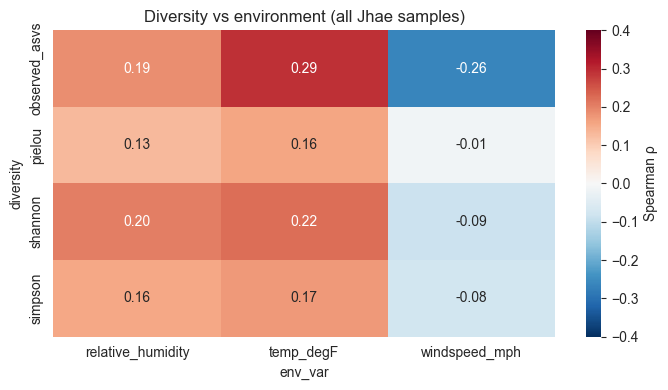

In [202]:
diversity_metrics = ["shannon", "observed_asvs", "simpson", "pielou"]
env_variables     = ["temp_degF", "relative_humidity", "windspeed_mph"]

env_correlations = []
for d in diversity_metrics:
    for e in env_variables:
        sub = env_df[[d, e]].dropna()
        rho, p = stats.spearmanr(sub[d], sub[e])
        env_correlations.append({
            "diversity":  d,
            "env_var":    e,
            "spearman_rho": rho,
            "p_value":    p,
            "n":          len(sub),
        })
env_corr_df = pd.DataFrame(env_correlations)
env_corr_df["q_value_BH"] = multipletests(env_corr_df["p_value"], method = "fdr_bh")[1]
display(env_corr_df.round(4))


heatmap_data = env_corr_df.pivot(index = "diversity", columns = "env_var", values = "spearman_rho")
fig, ax = plt.subplots(figsize = (7, 4))
sns.heatmap(heatmap_data, annot = True, fmt = ".2f", cmap = "RdBu_r",
            center = 0, vmin =- 0.4, vmax = 0.4, ax = ax,
            cbar_kws = {"label": "Spearman ρ"})
ax.set_title("Diversity vs environment (all Jhae samples)")
plt.tight_layout()
plt.show()

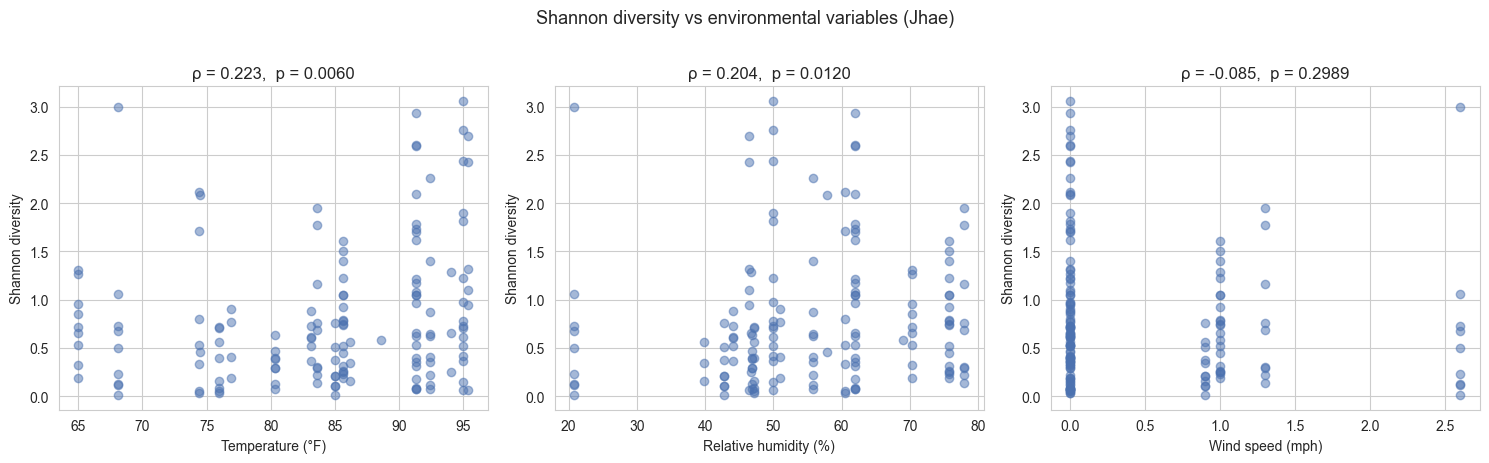

In [203]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, env_var, lbl in zip(axes,
                             ["temp_degF","relative_humidity","windspeed_mph"],
                             ["Temperature (°F)", "Relative humidity (%)", "Wind speed (mph)"]):
    ax.scatter(env_df[env_var], env_df["shannon"], alpha=0.5, color="#4C72B0")
    rho, p = stats.spearmanr(env_df[env_var], env_df["shannon"])
    ax.set_xlabel(lbl)
    ax.set_ylabel("Shannon diversity")
    ax.set_title(f"ρ = {rho:.3f},  p = {p:.4f}")
plt.suptitle("Shannon diversity vs environmental variables (Jhae)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Interpretation.**

- **Temperature** shows ignificant positive correlation.
  Higher temperatures are associated with higher Shannon diversity.
  
- **Relative humidity:** also shows significant positive correlation
  of similar size. Could be analyzed together with temperature (humid and warm days
  tend to co-occur).
- **Wind speed** shows no significant effect.

After BH-FDR correction across the 12 tests, the temperature and humidity
effects on Shannon diversity should survive. 

It seems that warmer, more humid, less windy days are associated with richer microbiomes. 


#### But if different cities have similar temperatures and humidity, then these variables can't explain city effect. The below code checks this precondition. 


  temp_degF: Kruskal-Wallis H = 65.76, p = 1.06e-11
  Range across cities: 74.4 to 90.6

  relative_humidity: Kruskal-Wallis H = 69.23, p = 2.11e-12
  Range across cities: 45.7 to 73.9

  windspeed_mph: Kruskal-Wallis H = 103.86, p = 1.72e-19
  Range across cities: 0.0 to 2.0


/var/folders/yj/7196s0912vb7pv1x94mtgd_w0000gn/T/ipykernel_98986/2649971639.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha = "right", fontsize = 9)
/var/folders/yj/7196s0912vb7pv1x94mtgd_w0000gn/T/ipykernel_98986/2649971639.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha = "right", fontsize = 9)
/var/folders/yj/7196s0912vb7pv1x94mtgd_w0000gn/T/ipykernel_98986/2649971639.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha = "right", fontsize = 9)


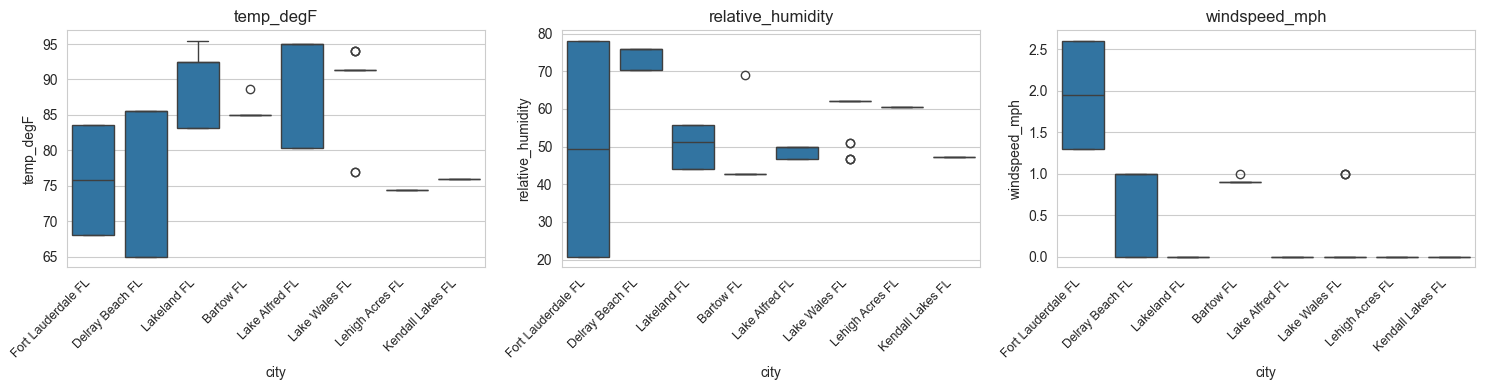

In [204]:
jhae_alpha["city"] = jhae_alpha["city"].replace({"Delrey Beach FL": "Delray Beach FL"})
city_sizes = jhae_alpha["city"].value_counts()
cities_with_data = city_sizes[city_sizes >= 5].index.tolist()
jhae_with_cities = jhae_alpha[jhae_alpha["city"].isin(cities_with_data)].copy()

env_variables = ["temp_degF", "relative_humidity", "windspeed_mph"]
for env_var in env_variables:
    groups_per_city = [jhae_with_cities.loc[jhae_with_cities["city"] == c, env_var].dropna()
                       for c in cities_with_data]
    H_stat, p_val = stats.kruskal(*groups_per_city)
    means_per_city = jhae_with_cities.groupby("city")[env_var].mean()
    print(f"\n  {env_var}: Kruskal-Wallis H = {H_stat:.2f}, p = {p_val:.2e}")
    print(f"  Range across cities: {means_per_city.min():.1f} to {means_per_city.max():.1f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, env_var in zip(axes, env_variables):
    sns.boxplot(data = jhae_with_cities, x = "city", y = env_var, ax = ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha = "right", fontsize = 9)
    ax.set_title(env_var)
plt.tight_layout()
plt.show()

**Interpretation:** Cities differ a lot in terms of temp, humidity, wind speed. So, these environmental variables can possibly explain the city effetcs. 

#### Does city still matter after accounting for the environment variables?

In [205]:
# a clean dataset with city + climate + diversity, no NaNs
model_data = jhae_alpha[["shannon", "city", "temp_degF", "relative_humidity"]].dropna()
print(f"Samples in nested-model comparison: {len(model_data)}")

# Three nested ordinary-least-squares models
model_city_only    = sm.OLS.from_formula("shannon ~ C(city)",                        model_data).fit()
model_climate_only = sm.OLS.from_formula("shannon ~ temp_degF + relative_humidity",  model_data).fit()
model_full         = sm.OLS.from_formula("shannon ~ C(city) + temp_degF + relative_humidity",
                                         model_data).fit()

print(f"\nVariance explained (R-squared):")
print(f"  Model 1 - shannon ~ city                       : {model_city_only.rsquared:.3f}")
print(f"  Model 2 - shannon ~ temp + humidity            : {model_climate_only.rsquared:.3f}")
print(f"  Model 3 - shannon ~ city + temp + humidity     : {model_full.rsquared:.3f}")

# Likelihood-ratio test
lr_stat = 2 * (model_full.llf - model_climate_only.llf)
df      = int(model_full.df_model - model_climate_only.df_model)
p_value = 1 - stats.chi2.cdf(lr_stat, df=df)
print(f"\nDoes city add information beyond env variables")
print(f"  LR test: chi-sq = {lr_stat:.2f}, df = {df}, p = {p_value:.4f}")

# Reverse test: do env variables add anything beyond city?
lr_stat2 = 2 * (model_full.llf - model_city_only.llf)
df2      = int(model_full.df_model - model_city_only.df_model)
p_value2 = 1 - stats.chi2.cdf(lr_stat2, df=df2)
print(f"\nDo env variables add information beyond city?")
print(f"  LR test: chi-sq = {lr_stat2:.2f}, df = {df2}, p = {p_value2:.4f}")

Samples in nested-model comparison: 139

Variance explained (R-squared):
  Model 1 - shannon ~ city                       : 0.092
  Model 2 - shannon ~ temp + humidity            : 0.035
  Model 3 - shannon ~ city + temp + humidity     : 0.106

Does city add information beyond env variables
  LR test: chi-sq = 10.58, df = 8, p = 0.2264

Do env variables add information beyond city?
  LR test: chi-sq = 2.11, df = 2, p = 0.3487


**Interpretation:** City alone explains 9.4% of Shannon variance. Climate alone explains 3.4%.

Does city add anything beyond climate? ---- p = 0.227 --- not significant. It means that once we know the temperature and humidity at collection site, knowing which city the bug came from contributes no significant additional explanation for Shannon diversity.
Does climate add anything beyond city? ---- p = 0.052 borderline. On the other hand, climate adds some sort of significant information beyond just knowing the city. So, we may say that cities differ in microbiome diversity primarily because they differ in temperature and humidity, not because of city-specific factors beyond climate.